In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('C:/Users/vipul/Downloads/mnist_digits_train.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [3]:
df['784'].unique()

array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8])

**Step 1** - Define the data

In [4]:
X = df.drop(columns = ['784'])
y = df['784']

In [5]:
y

0        5
1        0
2        4
3        1
4        9
        ..
59995    8
59996    3
59997    5
59998    6
59999    8
Name: 784, Length: 60000, dtype: int64

In [6]:
from keras.utils import to_categorical
yt = to_categorical(y)
yt

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]], shape=(60000, 10))

In [7]:
X.shape

(60000, 784)

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

Xs = scaler.fit_transform(X)

In [9]:
#plt.imshow(X.values[90].reshape(28,28) , cmap='gray')
#plt.show()

In [10]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(Xs,yt)

In [47]:
xtrain.shape

(45000, 784)

In [11]:
xtrain.shape

(45000, 784)

In [12]:
ytrain.shape

(45000, 10)

**Step 2** - Define neural network model

In [13]:
from keras import models, layers

model = models.Sequential()

model.add(layers.Dense(10 , input_shape = (784,)))

model.add(layers.Dense(10 , activation='sigmoid'))

C:\Users\vipul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │           7,850 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,960 (31.09 KB)

 Trainable params: 7,960 (31.09 KB)

 Non-trainable params: 0 (0.00 B)

**Step 3** - Compile the model

In [15]:
from keras import optimizers
sgd = optimizers.SGD(learning_rate = 0.01)

model.compile(optimizer = sgd, loss = 'categorical_crossentropy', metrics = ['accuracy'])

**Step 4**- Train the model

In [16]:
model.fit(xtrain,ytrain,
         epochs = 10,
         validation_data = (xtest,ytest))

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.7793 - loss: 0.8493 - val_accuracy: 0.8689 - val_loss: 0.4794
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8834 - loss: 0.4221 - val_accuracy: 0.8917 - val_loss: 0.3856
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8982 - loss: 0.3644 - val_accuracy: 0.8992 - val_loss: 0.3527
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9041 - loss: 0.3379 - val_accuracy: 0.9034 - val_loss: 0.3369
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9078 - loss: 0.3224 - val_accuracy: 0.9067 - val_loss: 0.3253
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.9133 - loss: 0.3118 - val_accuracy: 0.9096 - val_loss: 0.3166
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9135 - loss: 0.3038 - val_accuracy: 0.9120 - val_loss: 0.3111
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9154 - 

In [21]:
xtrain.shape

(45000, 784)

In [22]:
model.predict(xtest[10].reshape(1,784))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[8.0389194e-03, 7.6750305e-04, 2.2028448e-01, 9.4210744e-01,
        2.7222069e-02, 1.8539295e-01, 2.5017043e-05, 9.9996787e-01,
        5.2713203e-01, 9.9736106e-01]], dtype=float32)

In [23]:
print(np.argmax(model.predict(xtest[10].reshape(1,784))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
7


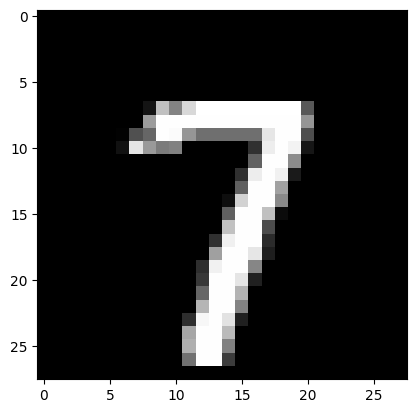

In [30]:
plt.imshow(xtest[10].reshape(28,28) , cmap='gray')
plt.show()

**Computer vision Example**

In [52]:
import cv2
img = cv2.imread("C:/Users/vipul/Downloads/five.jpg")
img = 255 - img
img = cv2.cvtColor(img , cv2.COLOR_BGR2GRAY)
img = cv2.resize(img , (28,28))
img

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   4,   0,   0,   0,   0,   2,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   1,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   1,   0, 219, 219,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   1,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [56]:
model.predict(scaler.transform(img.ravel().reshape(1,-1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


C:\Users\vipul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[0.250283  , 0.5921125 , 0.02065078, 0.7470088 , 0.53959954,
        0.9229288 , 0.27402604, 0.9158509 , 0.27104688, 0.53969   ]],
      dtype=float32)

In [58]:
print(np.argmax(model.predict(scaler.transform(img.ravel().reshape(1,-1)))))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
5


C:\Users\vipul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


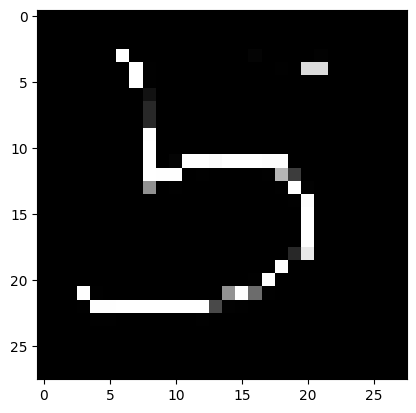

In [50]:
plt.imshow(img , cmap='gray')
plt.show()